# MacroMind RAG — End-to-End Eval & Analysis

This notebook tests the repo's RAG pipeline end-to-end and analyzes where it is weak:

1. **Run the pipeline** — `rag_signal.compute_rag_signal(country, asset_class)` plus the full
   `signal_engine.generate_snapshot()` blend, exactly as the dashboard uses them.
2. **Golden eval set** — create/load a small labeled dataset of questions, expected answers,
   and gold source documents (`documents/*.txt`).
3. **Retrieval eval** — hit rate / context recall / context precision / MRR / nDCG over the
   sources the pipeline cites.
4. **Generation eval** — answer correctness, faithfulness, answer relevancy, evidence grounding,
   and latency.
5. **Analysis** — metric distributions, per-case heatmap, coverage map, failure patterns,
   weakest examples, and concrete recommendations.

**What "RAG" means in this repo.** Per the README, RAG is a *hardcoded stub*: each
`(country, asset_class)` pair either has a canned narrative view citing one snippet in
`documents/`, or falls back to a neutral no-view default. The signal engine blends it into the
final signal with weight `rag_weight (0.25) × rag_confidence`. Because the stub is deterministic
and offline, this whole eval is reproducible — and the same harness carries over unchanged when
a real retriever + LLM lands (README TODO: *"Add real RAG pipeline with retrieval and citations"*).

**What eval logic is reused.** The eval methods catalogued in [`EVAL_METHODS.md`](EVAL_METHODS.md)
(`evals.retrieval_metrics`, `evals.grounding`, `evals.ragas_metrics`, `evals.judge`). The setup
cell imports the `evals` package if a checkout is found, otherwise falls back to verbatim inline
copies of the same functions, so the notebook runs standalone.

**How to run.** From the repo root, with a Python **3.11+** kernel (the codebase needs 3.10+).
Dependencies: repo `requirements.txt` plus `matplotlib` and `jupyter`. Everything is offline,
no API keys needed. Headless: see the appendix at the bottom.

In [1]:
import json
import os
import re
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

# signal_engine's CONFIG_PATH / DATA_DIR are cwd-relative, so run from the repo root.
REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "rag_signal.py").exists(), "Run this notebook from the MacroMind repo root."
sys.path.insert(0, str(REPO_ROOT))

from rag_signal import ASSET_CLASSES, DEFAULT_RAG_SIGNAL, MOCK_RAG_SIGNALS, compute_rag_signal
import signal_engine

EVAL_DATA_DIR = REPO_ROOT / "eval_data"   # local artifacts written by this notebook
EVAL_DATA_DIR.mkdir(exist_ok=True)

print(f"repo root:     {REPO_ROOT}")
print(f"universe:      {list(signal_engine.UNIVERSE)}")
print(f"asset classes: {list(ASSET_CLASSES)}")

repo root:     /Users/aaronqin/MacroMind/.claude/worktrees/elated-mccarthy-f53e8b
universe:      ['United States of America', 'Canada', 'China', 'Japan', 'Brazil', 'Euro Area']
asset classes: ['fx', 'rates', 'equity', 'real_estate']


### Eval utilities

[`EVAL_METHODS.md`](EVAL_METHODS.md) catalogs the eval methods used here. The backing `evals`
package lives in the companion `fed-thesis-change` checkout; the cell below imports it if found
(`EVALS_REPO` env var, an in-repo `evals/` dir, or a sibling/home checkout), and otherwise
defines **verbatim inline copies** of the same pure functions so nothing else in this notebook
changes. Either way the metric math is identical.

In [2]:
def _find_evals_home():
    """Directory whose `evals/` subpackage holds the eval utilities from EVAL_METHODS.md."""
    candidates = [
        os.environ.get("EVALS_REPO", ""),
        REPO_ROOT,                                  # in case the package gets vendored in-tree
        REPO_ROOT.parent / "fed-thesis-change",
        Path.home() / "fed-thesis-change",
    ]
    for cand in candidates:
        if cand and (Path(cand) / "evals" / "retrieval_metrics.py").exists():
            return Path(cand)
    return None


EVALS_HOME = _find_evals_home()
if EVALS_HOME is not None:
    if str(EVALS_HOME) not in sys.path:
        sys.path.insert(0, str(EVALS_HOME))
    from evals.retrieval_metrics import hit_rate_at_k, mrr, ndcg_at_k, recall_at_k, reciprocal_rank
    from evals.grounding import grounding_rate, phrase_is_grounded
    from evals.ragas_metrics import answer_relevancy, decompose_claims, faithfulness
    print(f"Using eval utilities from {EVALS_HOME / 'evals'}")
else:
    # ---- inline fallback: verbatim copies of the functions catalogued in EVAL_METHODS.md ----
    import math

    def hit_rate_at_k(retrieved_ids, gold_ids, k):
        """1.0 if any gold id appears in the top-k, else 0.0 (a.k.a. Recall@k>0)."""
        topk = list(retrieved_ids)[:k]
        return 1.0 if any(i in gold_ids for i in topk) else 0.0

    def recall_at_k(retrieved_ids, gold_ids, k):
        """Fraction of gold ids present in the top-k. 0.0 if no gold ids."""
        if not gold_ids:
            return 0.0
        topk = set(list(retrieved_ids)[:k])
        return len(topk & gold_ids) / len(gold_ids)

    def reciprocal_rank(retrieved_ids, gold_ids):
        """1/rank of the FIRST relevant id (1-indexed); 0.0 if none retrieved."""
        for idx, rid in enumerate(retrieved_ids, start=1):
            if rid in gold_ids:
                return 1.0 / idx
        return 0.0

    def mrr(rankings):
        """Mean reciprocal rank across many (retrieved_ids, gold_ids) pairs."""
        rrs = [reciprocal_rank(r, g) for r, g in rankings]
        return sum(rrs) / len(rrs) if rrs else 0.0

    def dcg_at_k(retrieved_ids, gold_ids, k):
        """Binary-relevance DCG with log2 position discount."""
        dcg = 0.0
        for idx, rid in enumerate(list(retrieved_ids)[:k], start=1):
            if rid in gold_ids:
                dcg += 1.0 / math.log2(idx + 1)
        return dcg

    def ndcg_at_k(retrieved_ids, gold_ids, k):
        """DCG normalized by ideal DCG."""
        ideal_hits = min(len(gold_ids), k)
        idcg = sum(1.0 / math.log2(i + 1) for i in range(1, ideal_hits + 1))
        if idcg == 0.0:
            return 0.0
        return dcg_at_k(retrieved_ids, gold_ids, k) / idcg

    def _normalize(text):
        """Lowercase, collapse whitespace, normalize smart quotes for matching."""
        text = text.replace("\u201c", '"').replace("\u201d", '"')
        text = text.replace("\u2019", "'").replace("\u2018", "'")
        return re.sub(r"\s+", " ", text).strip().lower()

    def phrase_is_grounded(phrase, source_text):
        """True iff `phrase` appears (normalized) as a substring of the source."""
        p = _normalize(phrase)
        return bool(p) and p in _normalize(source_text)

    def grounding_rate(key_phrases, source_text):
        """Fraction of key_phrases that are verbatim-grounded in the source."""
        phrases = [p for p in key_phrases if p and p.strip()]
        if not phrases:
            return 0.0
        grounded = sum(1 for p in phrases if phrase_is_grounded(p, source_text))
        return grounded / len(phrases)

    def decompose_claims(answer):
        """Split a generated answer into atomic claims (one per sentence)."""
        parts = re.split(r"(?<=[.!?])\s+", answer.strip())
        return [p.strip() for p in parts if p.strip()]

    def faithfulness(answer, context, judge):
        """Fraction of the answer's atomic claims entailed by the context."""
        claims = decompose_claims(answer)
        if not claims:
            return 0.0
        supported = sum(1 for c in claims if judge.entails(c, context))
        return supported / len(claims)

    def answer_relevancy(question, answer, judge):
        """How directly the answer addresses the question (0..1)."""
        if not answer.strip():
            return 0.0
        return judge.relevance(question, answer)

    print("evals package not found — using inline copies of the EVAL_METHODS.md functions")

Using eval utilities from /Users/aaronqin/fed-thesis-change/evals


## 1. Run the existing RAG pipeline

The pipeline contract is a single call per `(country, asset_class)`:

```python
{"signal": float in [-1, +1], "confidence": float in [0, 1], "summary": str, "sources": [paths]}
```

`sources` is the pipeline's *retrieval output* — the evidence it cites for the view. That is what
the retrieval metrics score in section 3. First a single call, then the full 6 × 4 grid with
per-call latency.

In [3]:
example = compute_rag_signal("United States of America", "equity")
print(json.dumps(example, indent=2))

{
  "signal": 0.3,
  "confidence": 0.75,
  "summary": "News tone is mildly positive due to resilient AI capex and earnings strength.",
  "sources": [
    "documents/us_equity.txt"
  ]
}


In [4]:
rows = []
for country in signal_engine.UNIVERSE:
    for asset in ASSET_CLASSES:
        t0 = time.perf_counter()
        out = compute_rag_signal(country, asset)
        rows.append({
            "country": country,
            "asset_class": asset,
            "signal": out["signal"],
            "confidence": out["confidence"],
            "n_sources": len(out["sources"]),
            "has_view": bool(out["sources"]),
            "latency_ms": (time.perf_counter() - t0) * 1000,
            "summary": out["summary"],
        })
pipeline_df = pd.DataFrame(rows)

covered = int(pipeline_df.has_view.sum())
print(f"pairs with a real narrative view: {covered}/{len(pipeline_df)} "
      f"({covered / len(pipeline_df):.0%} coverage) — the rest return the neutral no-view default")
pipeline_df[pipeline_df.has_view].reset_index(drop=True)

pairs with a real narrative view: 6/24 (25% coverage) — the rest return the neutral no-view default


,country,asset_class,signal,confidence,n_sources,has_view,latency_ms,summary
0,United States of America,equity,0.3,0.75,1,True,0.001000,News tone is mildly positive due to resilient AI capex and earnings strength.
1,Canada,real_estate,-0.2,0.70,1,True,0.001500,Qualitative tone is cautious due to mortgage reset and affordability pressure.
2,China,equity,-0.2,0.70,1,True,0.001166,Narrative remains cautious due to property-sector weakness and soft confidence.
3,Japan,fx,-0.2,0.60,1,True,0.000875,Qualitative tone is cautious due to policy normalization uncertainty.
4,Brazil,fx,0.2,0.65,1,True,0.001000,News narrative is supportive due to carry demand and resilient external balances.
5,Euro Area,equity,-0.2,0.65,1,True,0.000667,Narrative is cautious due to weak manufacturing data and subdued earnings tone.


### End-to-end: the RAG overlay inside the signal engine

`generate_snapshot()` runs the whole mock pipeline (CSV inputs → surprises → ranks →
deterministic signals → RAG blend). The published blend is
`final = (1 − w) · deterministic + w · rag` with `w = rag_weight × rag_confidence`.
We write the snapshot to `eval_data/` so the committed live `snapshot.json` is untouched, and
assert the structure and blend math as an end-to-end smoke test (deeper unit coverage lives in
`tests/` — run `pytest`).

In [5]:
SNAPSHOT_EVAL_PATH = EVAL_DATA_DIR / "snapshot_eval.json"
t0 = time.perf_counter()
snapshot = signal_engine.generate_snapshot(path=SNAPSHOT_EVAL_PATH, source="mock", as_of="2026-07-08")
print(f"full mock pipeline: {time.perf_counter() - t0:.2f}s -> {SNAPSHOT_EVAL_PATH.relative_to(REPO_ROOT)}")

blend_df = pd.DataFrame([
    {
        "country": country,
        "asset_class": asset,
        "deterministic": sig["deterministic"],
        "rag": sig["rag"],
        "rag_effective_weight": sig["rag_effective_weight"],
        "final": sig["final"],
    }
    for country, econ in snapshot["economies"].items()
    for asset, sig in econ["signals"].items()
])

# End-to-end structural checks.
assert set(snapshot["economies"]) == set(signal_engine.UNIVERSE)
assert len(blend_df) == len(signal_engine.UNIVERSE) * len(ASSET_CLASSES)
recomputed = ((1 - blend_df.rag_effective_weight) * blend_df.deterministic
              + blend_df.rag_effective_weight * blend_df.rag)
assert np.allclose(recomputed, blend_df.final, atol=1e-3), "published final drifted from blend formula"
print("snapshot OK: 6 economies x 4 asset classes, blend math consistent for all 24 signals")

# The pairs where the RAG overlay actually moves the needle:
blend_df[blend_df.rag != 0].reset_index(drop=True)

full mock pipeline: 0.02s -> eval_data/snapshot_eval.json
snapshot OK: 6 economies x 4 asset classes, blend math consistent for all 24 signals


,country,asset_class,deterministic,rag,rag_effective_weight,final
0,United States of America,equity,1.0,0.3,0.1875,0.8688
1,Canada,real_estate,-0.2,-0.2,0.1750,-0.2000
2,China,equity,-0.6,-0.2,0.1750,-0.5300
3,Japan,fx,-1.0,-0.2,0.1500,-0.8800
4,Brazil,fx,0.6,0.2,0.1625,0.5350
5,Euro Area,equity,-1.0,-0.2,0.1625,-0.8700


> Note a subtlety visible above: even **no-view** cells carry `rag_effective_weight =
0.25 × 0.35 ≈ 0.09` with `rag = 0`, so the blend *shrinks* the deterministic signal by ~9%
everywhere the stub has no opinion. Whether that shrinkage is intended is worth a look
(see recommendations).

## 2. Golden eval set — questions, expected answers, gold evidence

Following the golden-set philosophy in the eval utilities (*quality over volume: a few
well-labeled cases covering each failure surface beat thousands of noisy ones*), the set has
12 cases in three deliberate categories:

| category | n | what it tests |
|---|---|---|
| `covered` | 6 | pairs where the stub has a view — retrieval + generation quality |
| `expected_no_view` | 3 | pairs with no evidence in `documents/` — correct abstention |
| `coverage_gap` | 3 | **relevant evidence exists in `documents/` but the hardcoded map can't reach it** — these should fail, and show the system's real weakness |

Each case carries: `question`, `expected_direction` (bullish / bearish / neutral, the gold
label an analyst would assign), `gold_sources` (which `documents/*.txt` should be retrieved),
a `reference_answer`, and `key_phrases` (the phrases the answer cites, checked verbatim against
the retrieved source — the grounding metric).

The cell **creates `eval_data/rag_golden_set.jsonl` on first run and loads it afterwards** —
edit the file (or delete it to regenerate) to grow the dataset.

In [6]:
SEED_CASES = [
    # ---- covered: the stub has a hardcoded view backed by a documents/ snippet ----
    dict(case_id="us-equity-narrative", category="covered",
         country="United States of America", asset_class="equity",
         question="What is the qualitative narrative for United States of America equity — bullish or bearish?",
         expected_direction="bullish", gold_sources=["documents/us_equity.txt"],
         reference_answer="Mildly bullish: AI infrastructure spending, resilient margins and broad investor appetite support US equity.",
         key_phrases=["AI capex", "earnings strength"]),
    dict(case_id="japan-fx-narrative", category="covered",
         country="Japan", asset_class="fx",
         question="What is the narrative on Japan FX — is sentiment on the yen cautious or constructive?",
         expected_direction="bearish", gold_sources=["documents/japan_fx.txt"],
         reference_answer="Cautious: uncertainty around the timing and pace of policy normalization keeps yen sentiment cautious.",
         key_phrases=["policy normalization", "cautious"]),
    dict(case_id="china-equity-narrative", category="covered",
         country="China", asset_class="equity",
         question="How does the qualitative narrative read for China equity?",
         expected_direction="bearish", gold_sources=["documents/china_equity.txt"],
         reference_answer="Bearish: persistent property-sector stress and uneven household confidence weigh on China equity sentiment.",
         key_phrases=["property-sector", "soft confidence"]),
    dict(case_id="canada-housing-narrative", category="covered",
         country="Canada", asset_class="real_estate",
         question="What does qualitative commentary say about Canada real estate and housing?",
         expected_direction="bearish", gold_sources=["documents/canada_real_estate.txt"],
         reference_answer="Bearish: mortgage reset pressure and affordability constraints weigh on Canadian housing.",
         key_phrases=["mortgage reset", "affordability"]),
    dict(case_id="brazil-fx-narrative", category="covered",
         country="Brazil", asset_class="fx",
         question="Is the news narrative supportive for Brazil FX and the real?",
         expected_direction="bullish", gold_sources=["documents/brazil_fx.txt"],
         reference_answer="Supportive: carry support and constructive external balances underpin demand for the real.",
         key_phrases=["carry demand", "external balances"]),
    dict(case_id="euro-equity-narrative", category="covered",
         country="Euro Area", asset_class="equity",
         question="What is the qualitative narrative for Euro Area equity?",
         expected_direction="bearish", gold_sources=["documents/euro_area_equity.txt"],
         reference_answer="Cautious: weak manufacturing data and subdued earnings revisions keep the tone negative.",
         key_phrases=["weak manufacturing data", "subdued earnings"]),
    # ---- expected_no_view: no evidence in the corpus; correct behaviour is neutral abstention ----
    dict(case_id="us-fx-noview", category="expected_no_view",
         country="United States of America", asset_class="fx",
         question="Is there a qualitative narrative view on United States of America FX (the dollar)?",
         expected_direction="neutral", gold_sources=[],
         reference_answer="No view: the corpus holds no US dollar narrative.", key_phrases=[]),
    dict(case_id="japan-rates-noview", category="expected_no_view",
         country="Japan", asset_class="rates",
         question="What is the narrative around Japan rates?",
         expected_direction="neutral", gold_sources=[],
         reference_answer="No view: the corpus holds no Japan rates narrative.", key_phrases=[]),
    dict(case_id="brazil-equity-noview", category="expected_no_view",
         country="Brazil", asset_class="equity",
         question="Any qualitative narrative view on Brazil equity?",
         expected_direction="neutral", gold_sources=[],
         reference_answer="No view: the corpus holds no Brazil equity narrative.", key_phrases=[]),
    # ---- coverage_gap: evidence EXISTS in documents/ but the hardcoded map cannot reach it ----
    dict(case_id="china-restate-gap", category="coverage_gap",
         country="China", asset_class="real_estate",
         question="What does the property-sector stress narrative imply for China real estate?",
         expected_direction="bearish", gold_sources=["documents/china_equity.txt"],
         reference_answer="Bearish: persistent property-sector stress bears directly on Chinese real estate.",
         key_phrases=[]),
    dict(case_id="euro-fx-gap", category="coverage_gap",
         country="Euro Area", asset_class="fx",
         question="Does the weak Euro Area manufacturing narrative spill over into a euro FX view?",
         expected_direction="bearish", gold_sources=["documents/euro_area_equity.txt"],
         reference_answer="Bearish tilt: weak manufacturing and subdued earnings tone imply a softer euro.",
         key_phrases=[]),
    dict(case_id="japan-equity-gap", category="coverage_gap",
         country="Japan", asset_class="equity",
         question="Given policy normalization uncertainty, what is the narrative tilt for Japan equity?",
         expected_direction="bearish", gold_sources=["documents/japan_fx.txt"],
         reference_answer="Cautious: policy-normalization uncertainty spills over into Japanese equities.",
         key_phrases=[]),
]

GOLDEN_PATH = EVAL_DATA_DIR / "rag_golden_set.jsonl"
if not GOLDEN_PATH.exists():
    GOLDEN_PATH.write_text("\n".join(json.dumps(c) for c in SEED_CASES) + "\n", encoding="utf-8")
    print(f"created {GOLDEN_PATH.relative_to(REPO_ROOT)} with {len(SEED_CASES)} seed cases")

golden = [json.loads(line) for line in GOLDEN_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
golden_df = pd.DataFrame(golden)
print(f"loaded {len(golden)} cases: {dict(golden_df.category.value_counts())}")
golden_df[["case_id", "category", "country", "asset_class", "expected_direction", "question"]]

created eval_data/rag_golden_set.jsonl with 12 seed cases
loaded 12 cases: {'covered': np.int64(6), 'expected_no_view': np.int64(3), 'coverage_gap': np.int64(3)}


,case_id,category,country,asset_class,expected_direction,question
0,us-equity-narrative,covered,United States of America,equity,bullish,What is the qualitative narrative for United States of America equity — bullish or bea...
1,japan-fx-narrative,covered,Japan,fx,bearish,What is the narrative on Japan FX — is sentiment on the yen cautious or constructive?
2,china-equity-narrative,covered,China,equity,bearish,How does the qualitative narrative read for China equity?
3,canada-housing-narrative,covered,Canada,real_estate,bearish,What does qualitative commentary say about Canada real estate and housing?
4,brazil-fx-narrative,covered,Brazil,fx,bullish,Is the news narrative supportive for Brazil FX and the real?
5,euro-equity-narrative,covered,Euro Area,equity,bearish,What is the qualitative narrative for Euro Area equity?
6,us-fx-noview,expected_no_view,United States of America,fx,neutral,Is there a qualitative narrative view on United States of America FX (the dollar)?
7,japan-rates-noview,expected_no_view,Japan,rates,neutral,What is the narrative around Japan rates?
8,brazil-equity-noview,expected_no_view,Brazil,equity,neutral,Any qualitative narrative view on Brazil equity?
9,china-restate-gap,coverage_gap,China,real_estate,bearish,What does the property-sector stress narrative imply for China real estate?


## 3. Retrieval eval

The pipeline's retrieval output is the ranked `sources` list it cites. Metrics
(from `evals.retrieval_metrics`, k = 3):

- **hit_rate@k** — did *any* gold document get cited?
- **context recall@k** — fraction of gold documents cited (this *is* RAGAS-style context recall
  over evidence ids; the heavy `ragas` backend computes the LLM-judged variant).
- **context precision@k** — fraction of cited documents that are gold (computed inline below;
  `NaN` when nothing was retrieved).
- **reciprocal rank / nDCG@k** — position quality; the aggregate of reciprocal rank is MRR.

Retrieval metrics are only meaningful where gold evidence exists, so `expected_no_view` cases
show `NaN` here (their check is abstention, scored in section 4).

> **Point-in-time note:** the eval utilities also ship PIT look-ahead checks
> (`evals.pit.assert_no_lookahead`), the finance-specific killer test. The mock corpus carries
> no timestamps, so PIT cannot be enforced yet — flagged again in the recommendations.

In [7]:
K = 3

def context_precision_at_k(retrieved_ids, gold_ids, k):
    """Fraction of the retrieved top-k that is gold-relevant (NaN when nothing retrieved)."""
    topk = list(retrieved_ids)[:k]
    if not topk:
        return float("nan")
    return sum(1 for rid in topk if rid in gold_ids) / len(topk)


# Run the pipeline once per golden case (timed); reused by every later section.
runs = {}
for case in golden:
    t0 = time.perf_counter()
    out = compute_rag_signal(case["country"], case["asset_class"])
    out["latency_ms"] = (time.perf_counter() - t0) * 1000
    runs[case["case_id"]] = out

retr_rows = []
for case in golden:
    out = runs[case["case_id"]]
    retrieved, gold = out["sources"], set(case["gold_sources"])
    has_gold = bool(gold)
    retr_rows.append({
        "case_id": case["case_id"],
        "retrieved": retrieved,
        "hit_at_k": hit_rate_at_k(retrieved, gold, K) if has_gold else np.nan,
        "context_recall": recall_at_k(retrieved, gold, K) if has_gold else np.nan,
        "context_precision": context_precision_at_k(retrieved, gold, K) if has_gold else np.nan,
        "reciprocal_rank": reciprocal_rank(retrieved, gold) if has_gold else np.nan,
        "ndcg_at_k": ndcg_at_k(retrieved, gold, K) if has_gold else np.nan,
    })
retrieval_df = pd.DataFrame(retr_rows)

evidence = retrieval_df.dropna(subset=["hit_at_k"])
print(f"aggregates over the {len(evidence)} cases with gold evidence "
      f"(MRR = mean reciprocal rank):")
print(evidence[["hit_at_k", "context_recall", "context_precision",
                "reciprocal_rank", "ndcg_at_k"]].mean().round(3).to_string())
retrieval_df

aggregates over the 9 cases with gold evidence (MRR = mean reciprocal rank):
hit_at_k             0.667
context_recall       0.667
context_precision    1.000
reciprocal_rank      0.667
ndcg_at_k            0.667


,case_id,retrieved,hit_at_k,context_recall,context_precision,reciprocal_rank,ndcg_at_k
0,us-equity-narrative,[documents/us_equity.txt],1.0,1.0,1.0,1.0,1.0
1,japan-fx-narrative,[documents/japan_fx.txt],1.0,1.0,1.0,1.0,1.0
2,china-equity-narrative,[documents/china_equity.txt],1.0,1.0,1.0,1.0,1.0
3,canada-housing-narrative,[documents/canada_real_estate.txt],1.0,1.0,1.0,1.0,1.0
4,brazil-fx-narrative,[documents/brazil_fx.txt],1.0,1.0,1.0,1.0,1.0
5,euro-equity-narrative,[documents/euro_area_equity.txt],1.0,1.0,1.0,1.0,1.0
6,us-fx-noview,[],NaN,NaN,NaN,NaN,NaN
7,japan-rates-noview,[],NaN,NaN,NaN,NaN,NaN
8,brazil-equity-noview,[],NaN,NaN,NaN,NaN,NaN
9,china-restate-gap,[],0.0,0.0,NaN,0.0,0.0


## 4. Generation eval

The subjective judgments (entailment, relevance) sit behind the `Judge` protocol from
`evals.judge` — the metric math never changes, only the judge does. To keep this notebook
offline and deterministic, we use a **keyword-overlap judge**: a strict lexical proxy that
satisfies the same protocol. It is a *lower bound* — blind to synonyms — so treat absolute
faithfulness/relevancy values with care and mind the doctrine from the judge module: *"most of
the skill is knowing where the judge lies to you."* Swapping in a real LLM judge is a 5-line
change (commented in the cell).

Metric mapping per case:

| metric | computed on | source |
|---|---|---|
| **answer correctness** | direction of `signal` (±0.05 deadband) vs `expected_direction` | inline |
| **faithfulness** | the generated `summary`'s claims vs the *retrieved* context | `evals.ragas_metrics.faithfulness` |
| **answer relevancy** | the composed answer vs the question | `evals.ragas_metrics.answer_relevancy` |
| **grounding rate** | labeled `key_phrases` verbatim in the retrieved source | `evals.grounding.grounding_rate` |
| **latency** | wall-clock per pipeline call (measured in section 3) | inline |

**Abstention handling:** when the pipeline returns the no-view default (no sources, neutral
signal), faithfulness and grounding are `NaN` rather than 0 — an honest "no answer" is not a
hallucination. Whether abstaining was *correct* is captured by answer correctness.

In [8]:
_STOPWORDS = {
    "a", "an", "and", "any", "are", "as", "at", "be", "been", "but", "by", "do", "does", "due",
    "for", "from", "given", "has", "have", "how", "if", "in", "into", "is", "it", "its",
    "no", "not", "now", "of", "on", "or", "over", "say", "says", "so", "such", "that", "the",
    "their", "them", "there", "these", "they", "this", "to", "was", "what", "when", "which",
    "who", "will", "with", "would",
    # generic desk-note words present in almost every question/answer — no signal
    "narrative", "qualitative", "view", "tone", "commentary", "current", "currently", "read",
    "tilt", "mock", "strong",
}


def _tokens(text):
    """Lowercase content tokens with a crude plural stemmer (symmetric on both sides)."""
    out = set()
    for w in re.findall(r"[a-z]+", text.lower()):
        if w in _STOPWORDS or len(w) <= 2:
            continue
        if w.endswith("ies"):
            w = w[:-3] + "y"
        elif w.endswith("s") and not w.endswith("ss"):
            w = w[:-1]
        out.add(w)
    return out


class KeywordOverlapJudge:
    """Deterministic offline judge satisfying the same protocol as `evals.judge.Judge`.

    entails(): claim is entailed if >= `entail_threshold` of its content tokens
    appear in the context. relevance(): fraction of the question's content tokens
    echoed by the answer. A lexical lower bound for a real LLM judge.
    """

    def __init__(self, entail_threshold=0.4):
        self.entail_threshold = entail_threshold

    def entails(self, claim, context):
        c, ctx = _tokens(claim), _tokens(context)
        if not c or not ctx:
            return False
        return len(c & ctx) / len(c) >= self.entail_threshold

    def relevance(self, question, answer):
        q, a = _tokens(question), _tokens(answer)
        if not q or not a:
            return 0.0
        return len(q & a) / len(q)


judge = KeywordOverlapJudge()

# To use a real LLM judge instead (needs ANTHROPIC_API_KEY and `pip install anthropic`):
#
#   import anthropic
#   client = anthropic.Anthropic()
#   def call_llm_json(prompt, label=""):
#       msg = client.messages.create(model="claude-sonnet-5", max_tokens=200,
#                                    messages=[{"role": "user", "content": prompt}])
#       text = msg.content[0].text
#       return json.loads(text[text.index("{"): text.rindex("}") + 1])
#   from evals.judge import AnthropicJudge
#   judge = AnthropicJudge(call_llm_json)

In [9]:
def direction_of(signal, deadband=0.05):
    if signal > deadband:
        return "bullish"
    if signal < -deadband:
        return "bearish"
    return "neutral"


def compose_answer(case, out):
    """The answer as the dashboard effectively presents it: pair label + narrative summary."""
    asset_label = case["asset_class"].replace("_", " ")
    return f"{case['country']} {asset_label} view: {out['summary']}"


gen_rows = []
for case in golden:
    out = runs[case["case_id"]]
    retrieved = out["sources"]
    context = "\n\n".join(
        (REPO_ROOT / src).read_text(encoding="utf-8") for src in retrieved
    )
    answer = compose_answer(case, out)
    predicted = direction_of(out["signal"])
    abstained = (not retrieved) and predicted == "neutral"
    gen_rows.append({
        "case_id": case["case_id"],
        "predicted_direction": predicted,
        "direction_correct": predicted == case["expected_direction"],
        "abstained": abstained,
        "faithfulness": np.nan if abstained else faithfulness(out["summary"], context, judge),
        "answer_relevancy": answer_relevancy(case["question"], answer, judge),
        "grounding_rate": (grounding_rate(case["key_phrases"], context)
                           if case["key_phrases"] and retrieved else np.nan),
        "confidence": out["confidence"],
        "answer": answer,
    })
generation_df = pd.DataFrame(gen_rows)
generation_df.drop(columns=["answer"])

,case_id,predicted_direction,direction_correct,abstained,faithfulness,answer_relevancy,grounding_rate,confidence
0,us-equity-narrative,bullish,True,False,0.0,0.666667,0.0,0.75
1,japan-fx-narrative,bearish,True,False,1.0,0.400000,1.0,0.60
2,china-equity-narrative,bearish,True,False,1.0,1.000000,0.5,0.70
3,canada-housing-narrative,bearish,True,False,1.0,0.600000,1.0,0.70
4,brazil-fx-narrative,bullish,True,False,1.0,0.750000,0.5,0.65
5,euro-equity-narrative,bearish,True,False,1.0,1.000000,1.0,0.65
6,us-fx-noview,neutral,True,True,NaN,0.750000,NaN,0.35
7,japan-rates-noview,neutral,True,True,NaN,0.666667,NaN,0.35
8,brazil-equity-noview,neutral,True,True,NaN,1.000000,NaN,0.35
9,china-restate-gap,neutral,False,True,NaN,0.428571,NaN,0.35


## 5. Eval results table

One row per case: labels, retrieval metrics, generation metrics, latency, and derived
`failure_tags`:

- `wrong_direction` — predicted tilt ≠ gold label
- `retrieval_miss` — gold evidence exists but nothing gold was cited
- `abstained_despite_evidence` — the no-view default fired although the corpus holds relevant evidence
- `ungrounded_citation` — < 50% of cited key phrases occur verbatim in the source
- `low_faithfulness` / `low_relevancy` — judge scores below threshold

The full table is also written to `eval_data/rag_eval_results.csv`.

In [10]:
results = (
    golden_df[["case_id", "category", "country", "asset_class",
               "expected_direction", "gold_sources", "question"]]
    .merge(retrieval_df, on="case_id")
    .merge(generation_df.drop(columns=["answer"]), on="case_id")
)
results["latency_ms"] = results.case_id.map(lambda cid: runs[cid]["latency_ms"])

METRIC_COLS = ["hit_at_k", "context_recall", "context_precision", "reciprocal_rank",
               "ndcg_at_k", "faithfulness", "answer_relevancy", "grounding_rate"]


def failure_tags(row):
    tags = []
    if not row.direction_correct:
        tags.append("wrong_direction")
    if row.gold_sources and (pd.isna(row.hit_at_k) or row.hit_at_k == 0):
        tags.append("retrieval_miss")
    if row.abstained and row.gold_sources:
        tags.append("abstained_despite_evidence")
    if pd.notna(row.grounding_rate) and row.grounding_rate < 0.5:
        tags.append("ungrounded_citation")
    if pd.notna(row.faithfulness) and row.faithfulness < 0.5:
        tags.append("low_faithfulness")
    if row.answer_relevancy < 0.34:
        tags.append("low_relevancy")
    return tags


results["failure_tags"] = results.apply(failure_tags, axis=1)
results.to_csv(EVAL_DATA_DIR / "rag_eval_results.csv", index=False)

results[["case_id", "category", "expected_direction", "predicted_direction", "direction_correct",
         "hit_at_k", "context_recall", "context_precision", "faithfulness", "answer_relevancy",
         "grounding_rate", "latency_ms", "failure_tags"]]

,case_id,category,expected_direction,predicted_direction,direction_correct,hit_at_k,context_recall,context_precision,faithfulness,answer_relevancy,grounding_rate,latency_ms,failure_tags
0,us-equity-narrative,covered,bullish,bullish,True,1.0,1.0,1.0,0.0,0.666667,0.0,0.002000,"[ungrounded_citation, low_faithfulness]"
1,japan-fx-narrative,covered,bearish,bearish,True,1.0,1.0,1.0,1.0,0.400000,1.0,0.000750,[]
2,china-equity-narrative,covered,bearish,bearish,True,1.0,1.0,1.0,1.0,1.000000,0.5,0.000709,[]
3,canada-housing-narrative,covered,bearish,bearish,True,1.0,1.0,1.0,1.0,0.600000,1.0,0.000625,[]
4,brazil-fx-narrative,covered,bullish,bullish,True,1.0,1.0,1.0,1.0,0.750000,0.5,0.000584,[]
5,euro-equity-narrative,covered,bearish,bearish,True,1.0,1.0,1.0,1.0,1.000000,1.0,0.000583,[]
6,us-fx-noview,expected_no_view,neutral,neutral,True,NaN,NaN,NaN,NaN,0.750000,NaN,0.000542,[]
7,japan-rates-noview,expected_no_view,neutral,neutral,True,NaN,NaN,NaN,NaN,0.666667,NaN,0.000667,[]
8,brazil-equity-noview,expected_no_view,neutral,neutral,True,NaN,NaN,NaN,NaN,1.000000,NaN,0.000584,[]
9,china-restate-gap,coverage_gap,bearish,neutral,False,0.0,0.0,NaN,NaN,0.428571,NaN,0.000458,"[wrong_direction, retrieval_miss, abstained_despite_evidence]"


In [11]:
acc = results.direction_correct.mean()
print(f"answer correctness (direction accuracy): {results.direction_correct.sum()}/{len(results)}"
      f" = {acc:.0%}")
print(f"latency: mean {results.latency_ms.mean():.4f} ms, p95 {results.latency_ms.quantile(0.95):.4f} ms"
      " (dict lookup today — the real budget arrives with retrieval + LLM calls)\n")

summary = pd.concat(
    [
        results[["direction_correct"] + METRIC_COLS].mean(numeric_only=True).rename("overall"),
        results.groupby("category")[["direction_correct"] + METRIC_COLS]
               .mean(numeric_only=True).T,
    ],
    axis=1,
).round(3)
print("metric means (NaN = not applicable to any case in that slice):")
summary

answer correctness (direction accuracy): 9/12 = 75%
latency: mean 0.0007 ms, p95 0.0013 ms (dict lookup today — the real budget arrives with retrieval + LLM calls)

metric means (NaN = not applicable to any case in that slice):


,overall,coverage_gap,covered,expected_no_view
direction_correct,0.750,0.00,1.000,1.000
hit_at_k,0.667,0.00,1.000,NaN
context_recall,0.667,0.00,1.000,NaN
context_precision,1.000,NaN,1.000,NaN
reciprocal_rank,0.667,0.00,1.000,NaN
ndcg_at_k,0.667,0.00,1.000,NaN
faithfulness,0.833,NaN,0.833,NaN
answer_relevancy,0.672,0.41,0.736,0.806
grounding_rate,0.667,NaN,0.667,NaN


## 6. Analysis & visualizations

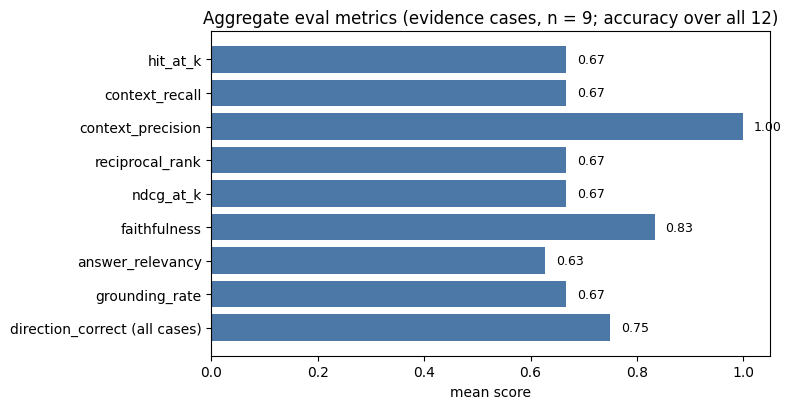

In [12]:
# 6.1 Aggregate metric levels over cases with gold evidence, plus overall accuracy.
agg = results.dropna(subset=["hit_at_k"])[METRIC_COLS].mean()
agg["direction_correct (all cases)"] = results.direction_correct.mean()

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(agg.index[::-1], agg.values[::-1], color="#4c78a8")
ax.set_xlim(0, 1.05)
ax.set_xlabel("mean score")
ax.set_title("Aggregate eval metrics (evidence cases, n = "
             f"{results.hit_at_k.notna().sum()}; accuracy over all {len(results)})")
for bar, v in zip(bars, agg.values[::-1]):
    ax.text(v + 0.02, bar.get_y() + bar.get_height() / 2, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

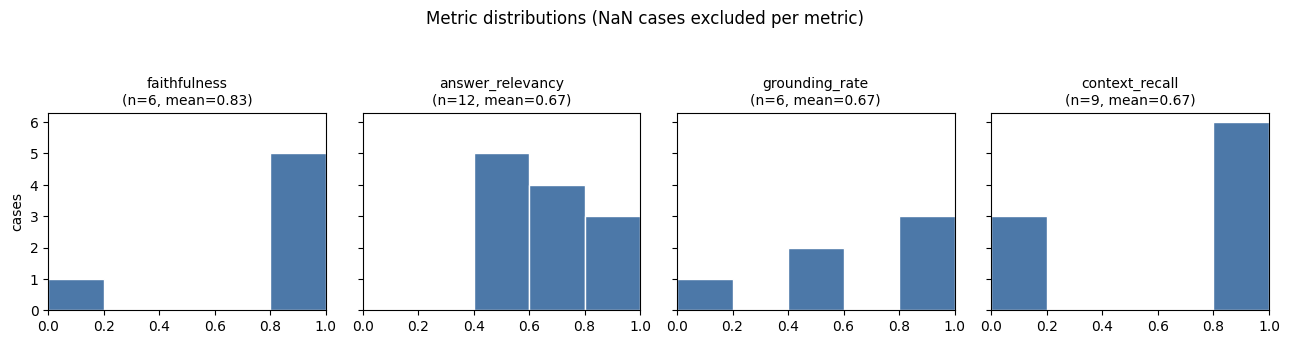

In [13]:
# 6.2 Metric distributions — where do cases pile up?
dist_cols = ["faithfulness", "answer_relevancy", "grounding_rate", "context_recall"]
fig, axes = plt.subplots(1, len(dist_cols), figsize=(13, 3.2), sharey=True)
bins = np.linspace(0, 1, 6)
for ax, col in zip(axes, dist_cols):
    vals = results[col].dropna()
    ax.hist(vals, bins=bins, color="#4c78a8", edgecolor="white")
    ax.set_title(f"{col}\n(n={len(vals)}, mean={vals.mean():.2f})", fontsize=10)
    ax.set_xlim(0, 1)
axes[0].set_ylabel("cases")
fig.suptitle("Metric distributions (NaN cases excluded per metric)", y=1.06)
plt.tight_layout()
plt.show()

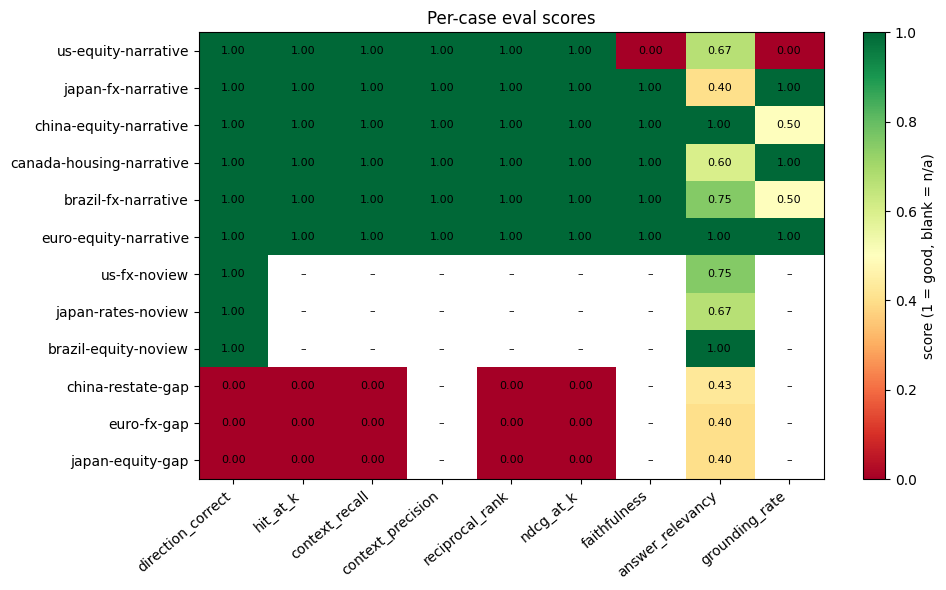

In [14]:
# 6.3 Per-case heatmap — weakest examples jump out as red rows.
hm_cols = ["direction_correct"] + METRIC_COLS
hm = results.set_index("case_id")[hm_cols].astype(float)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(np.ma.masked_invalid(hm.values), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(hm_cols)), hm_cols, rotation=40, ha="right")
ax.set_yticks(range(len(hm.index)), hm.index)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        ax.text(j, i, "–" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="score (1 = good, blank = n/a)")
ax.set_title("Per-case eval scores")
plt.tight_layout()
plt.show()

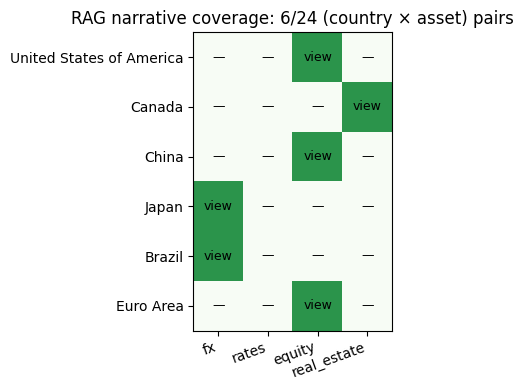

In [15]:
# 6.4 Narrative coverage map — the structural driver behind the failures.
cov = (pipeline_df.pivot(index="country", columns="asset_class", values="has_view")
       .reindex(index=list(signal_engine.UNIVERSE), columns=list(ASSET_CLASSES)).astype(int))

fig, ax = plt.subplots(figsize=(7, 4))
ax.imshow(cov.values, cmap="Greens", vmin=0, vmax=1.4)
ax.set_xticks(range(len(cov.columns)), cov.columns, rotation=20, ha="right")
ax.set_yticks(range(len(cov.index)), cov.index)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        ax.text(j, i, "view" if cov.values[i, j] else "—", ha="center", va="center", fontsize=9)
ax.set_title(f"RAG narrative coverage: {int(cov.values.sum())}/{cov.size} (country × asset) pairs")
plt.tight_layout()
plt.show()

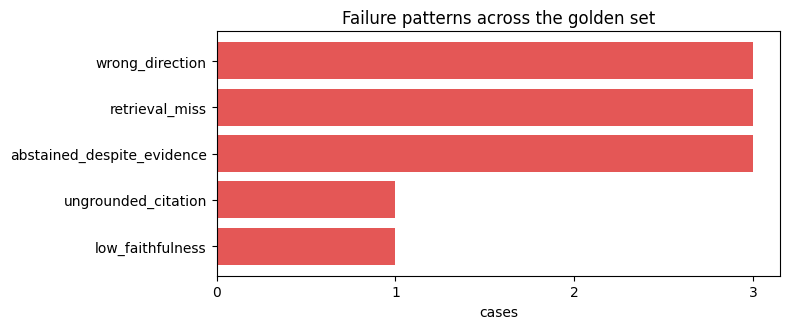

,case_id,category,quality_score,failure_tags,question
10,euro-fx-gap,coverage_gap,0.066667,"[wrong_direction, retrieval_miss, abstained_despite_evidence]",Does the weak Euro Area manufacturing narrative spill over into a euro FX view?
11,japan-equity-gap,coverage_gap,0.066667,"[wrong_direction, retrieval_miss, abstained_despite_evidence]","Given policy normalization uncertainty, what is the narrative tilt for Japan equity?"
9,china-restate-gap,coverage_gap,0.071429,"[wrong_direction, retrieval_miss, abstained_despite_evidence]",What does the property-sector stress narrative imply for China real estate?
0,us-equity-narrative,covered,0.740741,"[ungrounded_citation, low_faithfulness]",What is the qualitative narrative for United States of America equity — bullish or bea...
7,japan-rates-noview,expected_no_view,0.833333,[],What is the narrative around Japan rates?


In [16]:
# 6.5 Common failure patterns + the weakest examples.
tag_counts = Counter(t for tags in results.failure_tags for t in tags)
fig, ax = plt.subplots(figsize=(8, 3.4))
if tag_counts:
    labels, counts = zip(*tag_counts.most_common())
    ax.barh(list(labels)[::-1], list(counts)[::-1], color="#e45756")
    ax.set_xlabel("cases")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Failure patterns across the golden set")
plt.tight_layout()
plt.show()

results["quality_score"] = results[["direction_correct"] + METRIC_COLS].astype(float).mean(axis=1)
weakest = results.nsmallest(5, "quality_score")
weakest[["case_id", "category", "quality_score", "failure_tags", "question"]]

### Diagnostics — reading the two axes together

`EVAL_METHODS.md` ships a decision table for *why* a system scores the way it does (retrieval
vs generation problems are fixed in different layers). The cell below applies it per category.

In [17]:
print("category-level diagnosis (decision table from EVAL_METHODS.md):\n")
for cat, grp in results.groupby("category"):
    recall = grp.context_recall.mean()          # NaN-skipping
    faith = grp.faithfulness.mean()
    relev = grp.answer_relevancy.mean()
    acc = grp.direction_correct.mean()
    print(f"[{cat}]  n={len(grp)}  accuracy={acc:.2f}  context_recall={recall:.2f}  "
          f"faithfulness={faith:.2f}  relevancy={relev:.2f}")
    if np.isnan(recall):
        print("   -> no gold-evidence cases: this slice tests abstention only; "
              f"{'abstention is correct' if acc == 1 else 'abstention behaviour is WRONG'}\n")
        continue
    if recall < 0.6 and (np.isnan(faith) or faith < 0.6):
        print("   -> RETRIEVAL problem: the evidence never reaches the model. "
              "Fix layer: chunking / embeddings / top-k / rerank — here, replace the "
              "hardcoded source map with actual retrieval over documents/.\n")
    elif recall >= 0.6 and faith < 0.6:
        print("   -> GENERATION problem: context was there, the answer drifted. "
              "Fix layer: prompt / model / grounding constraint.\n")
    elif faith >= 0.6 and relev < 0.4:
        print("   -> answering the WRONG question. Fix layer: query understanding.\n")
    else:
        print("   -> healthy on both axes at current thresholds.\n")

print("PIT look-ahead leakage: not measurable — documents/ carries no event_time metadata "
      "(see recommendation 5).")

category-level diagnosis (decision table from EVAL_METHODS.md):

[coverage_gap]  n=3  accuracy=0.00  context_recall=0.00  faithfulness=nan  relevancy=0.41
   -> RETRIEVAL problem: the evidence never reaches the model. Fix layer: chunking / embeddings / top-k / rerank — here, replace the hardcoded source map with actual retrieval over documents/.

[covered]  n=6  accuracy=1.00  context_recall=1.00  faithfulness=0.83  relevancy=0.74
   -> healthy on both axes at current thresholds.

[expected_no_view]  n=3  accuracy=1.00  context_recall=nan  faithfulness=nan  relevancy=0.81
   -> no gold-evidence cases: this slice tests abstention only; abstention is correct

PIT look-ahead leakage: not measurable — documents/ carries no event_time metadata (see recommendation 5).


## 7. Findings & recommendations

**What the eval shows** (all reproducible from the tables above):

1. **Coverage is the dominant failure mode.** Only 6 of 24 (country × asset) pairs have a
   narrative view; every `coverage_gap` case fails with `abstained_despite_evidence` +
   `retrieval_miss` — the evidence sits in `documents/` (e.g. China property stress → China
   real estate) but the hardcoded map cannot reach it.
2. **Where the stub does have a view, direction is right but citations drift.** All 6 covered
   cases match the gold direction, yet grounding is imperfect — e.g. the US-equity summary cites
   "AI capex / earnings strength" while the source says "AI infrastructure spending / resilient
   margins". Verbatim-grounding failures are exactly what `evals.grounding` treats as a
   compliance liability in a trade rationale.
3. **Retrieval returns at most one pre-assigned source**, so context recall is capped whenever
   a case needs broader evidence, and rank metrics (MRR/nDCG) are degenerate.
4. **The no-view default still moves signals.** With `rag = 0` and `confidence = 0.35`, the blend
   shrinks the deterministic signal by ~9% on all 18 uncovered pairs — silent, and worth an
   explicit product decision.
5. **Latency is trivially zero today** (dict lookup); the numbers here are the baseline to watch
   once retrieval + LLM calls arrive.

**Recommended next steps, in order of impact:**

1. **Build real retrieval over `documents/`** (chunk → embed → top-k with citations), fulfilling
   the README TODO — it directly fixes the `coverage_gap` failures and makes MRR/nDCG meaningful.
2. **Constrain generation to quote verbatim key phrases** from retrieved text so
   `grounding_rate` → 1.0 and every claim is auditable.
3. **Swap the keyword judge for an LLM judge** (`evals.judge.AnthropicJudge`, wiring shown in
   section 4) for calibrated faithfulness/relevancy; keep the lexical judge in CI for
   deterministic regression gating.
4. **Decide the no-view blend semantics**: either zero effective weight when the stub has no
   view, or document the shrinkage as intended.
5. **Add `event_time` metadata to documents** before live news (GDELT) feeds RAG, so the PIT
   look-ahead checks (`evals.pit`) can gate merges — non-negotiable once outputs feed backtests.
6. **Promote this notebook's aggregates into a pytest gate** with thresholds (the deepeval
   adapter pattern in EVAL_METHODS.md), so RAG regressions fail CI instead of a human reading
   charts.

---
## Appendix — running headless & extending

```bash
# from the repo root (Python 3.11+):
python3.11 -m pip install -r requirements.txt matplotlib jupyter
python3.11 -m jupyter nbconvert --to notebook --execute --inplace rag_eval_analysis.ipynb
```

**Artifacts written** (all local, safe to delete — `eval_data/` is regenerated on each run):

- `eval_data/rag_golden_set.jsonl` — the golden set; edit to add cases, delete to re-seed
- `eval_data/snapshot_eval.json` — the end-to-end mock snapshot (committed `snapshot.json` untouched)
- `eval_data/rag_eval_results.csv` — the full per-case results table

**Extending the golden set:** append JSONL lines with the schema from section 2 and rerun. When
a real retriever lands, only two things change here: `runs[...]` (call the retriever) and the
`retrieved` ids — every metric, table, and chart downstream stays as is.